# EDA FitBit: analisis exploratorio de rutinas y actividad fisica

Este notebook realiza un flujo completo de analisis exploratorio inicial sobre un dataset anonimizado generado a partir de respuestas de encuesta y datos de uso de la aplicacion FitBit.

El objetivo es cargar, explorar, limpiar y visualizar el dataset para comprender su estructura, calidad y patrones principales antes de cualquier analisis avanzado.

## 1. Contexto del dataset

El dataset contiene registros agregados a nivel de usuario participante. Cada fila representa un usuario anonimizado de la encuesta y resume su perfil, objetivo de entrenamiento, rutina generada y actividad registrada durante una simulacion de 6 semanas.

Fuente: dataset propio anonimizado para el TFM FitBit.

Granularidad: una fila por participante.

Variables principales:
- Datos demograficos: grupo de edad, genero y provincia.
- Perfil fitness: objetivo, nivel, entorno, dias planificados y tiempo disponible.
- Salud: numero de enfermedades normalizadas y uso de medicacion.
- Actividad: numero de actividades, minutos, calorias y ejercicios registrados.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import unicodedata

DATA_CANDIDATES = [
    Path("../data/dataset.csv"),
    Path("data/dataset.csv"),
    Path.cwd().parent / "data" / "dataset.csv",
    Path.cwd() / "data" / "dataset.csv",
]

DATA_PATH = next((path.resolve() for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se ha encontrado data/dataset.csv. Ejecuta el notebook desde documentos_fitbit o desde documentos_fitbit/notebooks.")

CLEAN_PATH = DATA_PATH.parent / "dataset_clean.csv"

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 50)


def remove_accents(value):
    if isinstance(value, str):
        value = value.replace("\u00f1", "n").replace("\u00d1", "N")
        value = value.replace("\u00bf", "").replace("\u00a1", "")
        value = unicodedata.normalize("NFKD", value)
        return "".join(char for char in value if not unicodedata.combining(char))
    return value


print(f"Dataset localizado en: {DATA_PATH}")

Dataset localizado en: D:\Evolve\TFM\documentos_fitbit\data\dataset.csv


## 2. Carga del dataset

Se importa el CSV y se revisan dimensiones, primeras filas y tipos detectados automaticamente por pandas.

In [2]:
df = pd.read_csv(DATA_PATH)
for column in df.select_dtypes(include=["object", "string"]).columns:
    df[column] = df[column].map(remove_accents)

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 32 filas x 19 columnas


,participant_id,username,objective,level,environment,age_group,gender,province,bmi,disease_count,medicated,planned_training_days,available_minutes,adherence,routines_created,activities_created,activity_exercises_created,total_activity_minutes,total_activity_calories
0,P001,survey_001,fuerza,principiante,ambos,30-39,hombre,Sevilla,21.6,2,True,2,45,0.49,1,3,13,94,863.3
1,P002,survey_002,fuerza,principiante,ambos,50-59,hombre,Sevilla,27.7,1,True,2,35,0.49,1,5,22,158,1555.4
2,P003,survey_003,perdida_grasa,principiante,casa,40-49,mujer,Sevilla,24.5,0,True,2,35,0.57,1,7,31,216,1480.8
3,P004,survey_004,perdida_grasa,principiante,casa,NaN,mujer,Sevilla,24.0,0,False,3,40,0.62,1,10,46,375,2325.5
4,P005,survey_005,perdida_grasa,principiante,casa,40-49,mujer,Sevilla,22.2,0,False,3,40,0.62,1,12,54,444,2725.5


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   participant_id              32 non-null     str    
 1   username                    32 non-null     str    
 2   objective                   32 non-null     str    
 3   level                       32 non-null     str    
 4   environment                 32 non-null     str    
 5   age_group                   28 non-null     str    
 6   gender                      32 non-null     str    
 7   province                    32 non-null     str    
 8   bmi                         32 non-null     float64
 9   disease_count               32 non-null     int64  
 10  medicated                   32 non-null     bool   
 11  planned_training_days       32 non-null     int64  
 12  available_minutes           32 non-null     int64  
 13  adherence                   32 non-null     floa

## 3. Exploracion inicial

En esta seccion se identifica la estructura del dataset, se separan variables por tipo y se revisa la calidad inicial: nulos, duplicados, rangos y posibles incoherencias.

In [4]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
boolean_cols = df.select_dtypes(include=["bool"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Columnas numericas:", numeric_cols)
print("Columnas booleanas:", boolean_cols)
print("Columnas categoricas/texto:", categorical_cols)

Columnas numericas: ['bmi', 'disease_count', 'planned_training_days', 'available_minutes', 'adherence', 'routines_created', 'activities_created', 'activity_exercises_created', 'total_activity_minutes', 'total_activity_calories']
Columnas booleanas: ['medicated']
Columnas categoricas/texto: ['participant_id', 'username', 'objective', 'level', 'environment', 'age_group', 'gender', 'province']


C:\Users\marta\AppData\Local\Temp\ipykernel_12452\1008402068.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [5]:
missing = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda data: (data["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_pct", ascending=False)
)
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
age_group,4,12.5


In [6]:
duplicated_rows = df.duplicated().sum()
duplicated_participants = df["participant_id"].duplicated().sum()
duplicated_usernames = df["username"].duplicated().sum()

pd.DataFrame(
    {
        "control": ["filas duplicadas", "participant_id duplicado", "username duplicado"],
        "resultado": [duplicated_rows, duplicated_participants, duplicated_usernames],
    }
)

,control,resultado
0,filas duplicadas,0
1,participant_id duplicado,0
2,username duplicado,0


In [7]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bmi,32.0,26.109375,4.464943,20.60,23.125,24.65,28.0250,40.60
disease_count,32.0,0.468750,0.671271,0.00,0.000,0.00,1.0000,2.00
planned_training_days,32.0,2.750000,0.879883,2.00,2.000,3.00,3.0000,5.00
available_minutes,32.0,40.156250,8.843111,25.00,35.000,40.00,50.0000,55.00
adherence,32.0,0.606250,0.114039,0.49,0.490,0.62,0.6225,0.86
routines_created,32.0,1.000000,0.000000,1.00,1.000,1.00,1.0000,1.00
activities_created,32.0,9.906250,5.572741,2.00,5.000,8.50,12.2500,26.00
activity_exercises_created,32.0,44.218750,24.935704,8.00,24.750,39.50,54.2500,115.00
total_activity_minutes,32.0,332.343750,217.348183,44.00,170.750,277.00,420.0000,928.00
total_activity_calories,32.0,2952.587500,2322.884519,312.00,1411.975,2412.70,3244.7000,10428.30


In [8]:
for column in ["objective", "level", "environment", "age_group", "gender", "province", "medicated"]:
    print()
    print(column)
    print(df[column].value_counts(dropna=False))


objective
objective
fuerza           16
perdida_grasa    13
mantenimiento     3
Name: count, dtype: int64

level
level
principiante    24
intermedio       6
avanzado         2
Name: count, dtype: int64

environment
environment
ambos       16
casa        14
gimnasio     2
Name: count, dtype: int64

age_group
age_group
50-59    10
40-49     8
30-39     6
NaN       4
20-29     3
60-69     1
Name: count, dtype: int64

gender
gender
hombre    16
mujer     16
Name: count, dtype: int64

province
province
Sevilla    30
Malaga      1
Madrid      1
Name: count, dtype: int64

medicated
medicated
True     16
False    16
Name: count, dtype: int64


## 4. Revision de incoherencias y anomalias

Se revisan reglas basicas de calidad esperadas para este dominio:
- BMI positivo y dentro de un rango humano razonable.
- Adherencia entre 0 y 1.
- Dias de entrenamiento entre 1 y 7.
- Minutos, calorias y actividades no negativos.
- Una rutina por usuario, ya que el dataset se genero a nivel de participante.

In [9]:
quality_checks = {
    "bmi_fuera_de_rango_10_60": (~df["bmi"].between(10, 60)).sum(),
    "adherence_fuera_de_0_1": (~df["adherence"].between(0, 1)).sum(),
    "training_days_fuera_de_1_7": (~df["planned_training_days"].between(1, 7)).sum(),
    "available_minutes_no_positivo": (df["available_minutes"] <= 0).sum(),
    "activities_negativas": (df["activities_created"] < 0).sum(),
    "minutes_negativos": (df["total_activity_minutes"] < 0).sum(),
    "calories_negativas": (df["total_activity_calories"] < 0).sum(),
    "usuarios_sin_rutina": (df["routines_created"] == 0).sum(),
}

pd.DataFrame.from_dict(quality_checks, orient="index", columns=["registros_detectados"])

,registros_detectados
bmi_fuera_de_rango_10_60,0
adherence_fuera_de_0_1,0
training_days_fuera_de_1_7,0
available_minutes_no_positivo,0
activities_negativas,0
minutes_negativos,0
calories_negativas,0
usuarios_sin_rutina,0


In [10]:
df.assign(
    calories_per_minute=lambda data: data["total_activity_calories"] / data["total_activity_minutes"].replace(0, np.nan),
    minutes_per_activity=lambda data: data["total_activity_minutes"] / data["activities_created"].replace(0, np.nan),
)[["participant_id", "objective", "level", "bmi", "activities_created", "total_activity_minutes", "total_activity_calories", "calories_per_minute", "minutes_per_activity"]].sort_values(
    "total_activity_minutes", ascending=False
).head(10)

,participant_id,objective,level,bmi,activities_created,total_activity_minutes,total_activity_calories,calories_per_minute,minutes_per_activity
7,P008,fuerza,avanzado,26.8,26,928,10428.3,11.237392,35.692308
23,P024,fuerza,avanzado,26.0,21,861,8669.6,10.069222,41.000000
12,P013,fuerza,intermedio,33.9,18,667,7208.9,10.807946,37.055556
20,P021,fuerza,intermedio,22.6,18,634,4587.7,7.236120,35.222222
22,P023,fuerza,intermedio,24.3,17,608,6198.9,10.195559,35.764706
14,P015,perdida_grasa,principiante,28.9,13,444,4736.2,10.667117,34.153846
4,P005,perdida_grasa,principiante,22.2,12,444,2725.5,6.138514,37.000000
26,P027,fuerza,principiante,21.9,12,432,3065.9,7.096991,36.000000
9,P010,fuerza,principiante,20.6,11,416,3619.1,8.699760,37.818182
10,P011,mantenimiento,intermedio,26.3,15,414,3119.9,7.535990,27.600000


## 5. Limpieza y normalizacion

Decisiones aplicadas:

1. Se eliminan duplicados exactos y duplicados por `participant_id`, conservando el primer registro.
2. Se normalizan textos categoricos con minusculas, espacios controlados y valores consistentes.
3. Se transforma `medicated` a booleano si fuera necesario.
4. Se convierten columnas numericas a tipo numerico, forzando valores invalidos a nulo.
5. `age_group` se completa como `no informado`, porque el valor faltante no impide el analisis y representa ausencia de respuesta/correccion de fecha.
6. Se recortan variables acotadas: adherencia entre 0 y 1, dias planificados entre 1 y 7 y metricas de actividad con minimo 0.
7. Se crean variables derivadas utiles para el analisis: calorias por minuto, minutos por actividad y ejercicios por actividad.

In [11]:
clean = df.copy()

clean = clean.drop_duplicates()
clean = clean.drop_duplicates(subset=["participant_id"], keep="first")

text_columns = ["participant_id", "username", "objective", "level", "environment", "age_group", "gender", "province"]
for column in text_columns:
    clean[column] = clean[column].astype("string").str.strip().map(remove_accents)

category_mappings = {
    "objective": {
        "perdida_grasa": "perdida_grasa",
        "perdida de grasa": "perdida_grasa",
        "fuerza": "fuerza",
        "mantenimiento": "mantenimiento",
        "resistencia": "resistencia",
    },
    "level": {
        "principiante": "principiante",
        "intermedio": "intermedio",
        "avanzado": "avanzado",
    },
    "environment": {
        "casa": "casa",
        "ambos": "ambos",
        "ambas": "ambos",
        "gimnasio": "gimnasio",
    },
    "gender": {
        "hombre": "hombre",
        "mujer": "mujer",
    },
}

for column, mapping in category_mappings.items():
    clean[column] = clean[column].str.lower().map(mapping).fillna(clean[column].str.lower())

clean["age_group"] = clean["age_group"].replace({"": pd.NA, "nan": pd.NA, "<NA>": pd.NA}).fillna("no informado")
clean["province"] = clean["province"].replace({"": pd.NA, "nan": pd.NA, "<NA>": pd.NA}).fillna("no informado")
clean["medicated"] = clean["medicated"].astype(str).str.lower().map({"true": True, "false": False, "1": True, "0": False})

numeric_expected = [
    "bmi", "disease_count", "planned_training_days", "available_minutes", "adherence",
    "routines_created", "activities_created", "activity_exercises_created",
    "total_activity_minutes", "total_activity_calories",
]
for column in numeric_expected:
    clean[column] = pd.to_numeric(clean[column], errors="coerce")

clean["adherence"] = clean["adherence"].clip(0, 1)
clean["planned_training_days"] = clean["planned_training_days"].clip(1, 7)
for column in ["available_minutes", "activities_created", "activity_exercises_created", "total_activity_minutes", "total_activity_calories"]:
    clean[column] = clean[column].clip(lower=0)

clean["calories_per_minute"] = clean["total_activity_calories"] / clean["total_activity_minutes"].replace(0, np.nan)
clean["minutes_per_activity"] = clean["total_activity_minutes"] / clean["activities_created"].replace(0, np.nan)
clean["exercises_per_activity"] = clean["activity_exercises_created"] / clean["activities_created"].replace(0, np.nan)

clean.to_csv(CLEAN_PATH, index=False)
print(f"Dataset limpio guardado en: {CLEAN_PATH}")
clean.head()

Dataset limpio guardado en: D:\Evolve\TFM\documentos_fitbit\data\dataset_clean.csv


,participant_id,username,objective,level,environment,age_group,gender,province,bmi,disease_count,medicated,planned_training_days,available_minutes,adherence,routines_created,activities_created,activity_exercises_created,total_activity_minutes,total_activity_calories,calories_per_minute,minutes_per_activity,exercises_per_activity
0,P001,survey_001,fuerza,principiante,ambos,30-39,hombre,Sevilla,21.6,2,True,2,45,0.49,1,3,13,94,863.3,9.184043,31.333333,4.333333
1,P002,survey_002,fuerza,principiante,ambos,50-59,hombre,Sevilla,27.7,1,True,2,35,0.49,1,5,22,158,1555.4,9.844304,31.600000,4.400000
2,P003,survey_003,perdida_grasa,principiante,casa,40-49,mujer,Sevilla,24.5,0,True,2,35,0.57,1,7,31,216,1480.8,6.855556,30.857143,4.428571
3,P004,survey_004,perdida_grasa,principiante,casa,no informado,mujer,Sevilla,24.0,0,False,3,40,0.62,1,10,46,375,2325.5,6.201333,37.500000,4.600000
4,P005,survey_005,perdida_grasa,principiante,casa,40-49,mujer,Sevilla,22.2,0,False,3,40,0.62,1,12,54,444,2725.5,6.138514,37.000000,4.500000


In [12]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   participant_id              32 non-null     str    
 1   username                    32 non-null     str    
 2   objective                   32 non-null     str    
 3   level                       32 non-null     str    
 4   environment                 32 non-null     str    
 5   age_group                   32 non-null     str    
 6   gender                      32 non-null     str    
 7   province                    32 non-null     str    
 8   bmi                         32 non-null     float64
 9   disease_count               32 non-null     int64  
 10  medicated                   32 non-null     bool   
 11  planned_training_days       32 non-null     int64  
 12  available_minutes           32 non-null     int64  
 13  adherence                   32 non-null     floa

In [13]:
clean.isna().sum().to_frame("nulos_despues_limpieza")

,nulos_despues_limpieza
participant_id,0
username,0
objective,0
level,0
environment,0
age_group,0
gender,0
province,0
bmi,0
disease_count,0


## 6. Visualizaciones basicas

Se generan visualizaciones sencillas y legibles para responder a preguntas exploratorias:

1. Como se distribuye una variable numerica relevante?
2. Cuales son las categorias mas frecuentes?
3. Existen diferencias visuales entre grupos?
4. Existe relacion entre adherencia y actividad registrada?

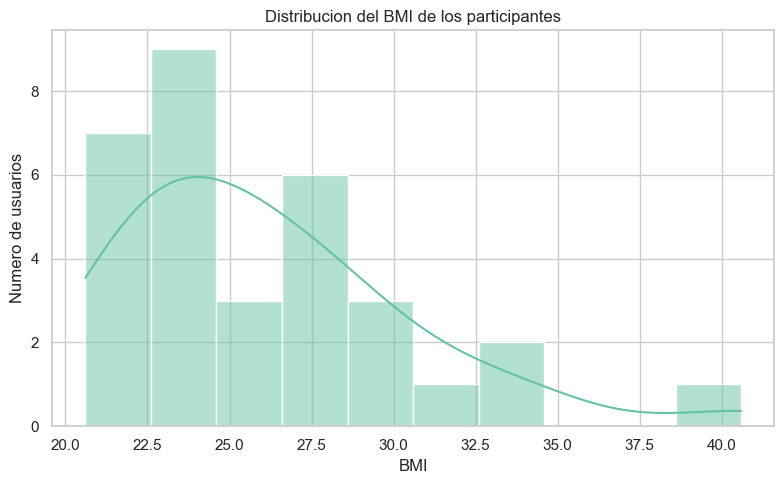

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(data=clean, x="bmi", bins=10, kde=True)
plt.title("Distribucion del BMI de los participantes")
plt.xlabel("BMI")
plt.ylabel("Numero de usuarios")
plt.tight_layout()
plt.show()

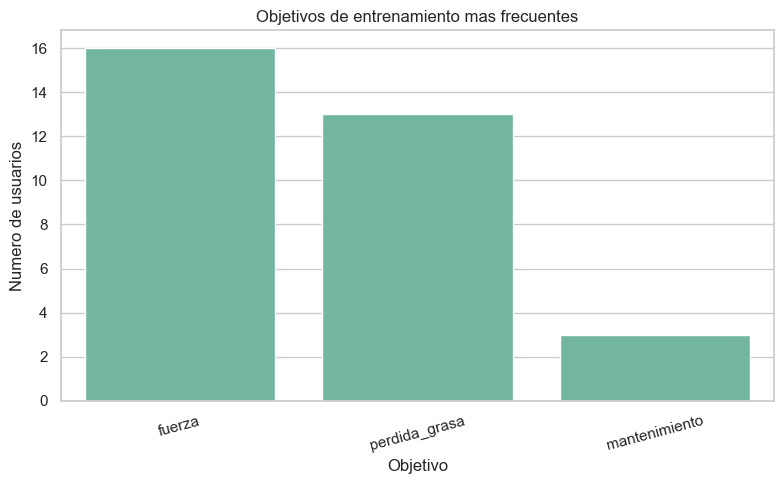

In [15]:
plt.figure(figsize=(8, 5))
order = clean["objective"].value_counts().index
sns.countplot(data=clean, x="objective", order=order)
plt.title("Objetivos de entrenamiento mas frecuentes")
plt.xlabel("Objetivo")
plt.ylabel("Numero de usuarios")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

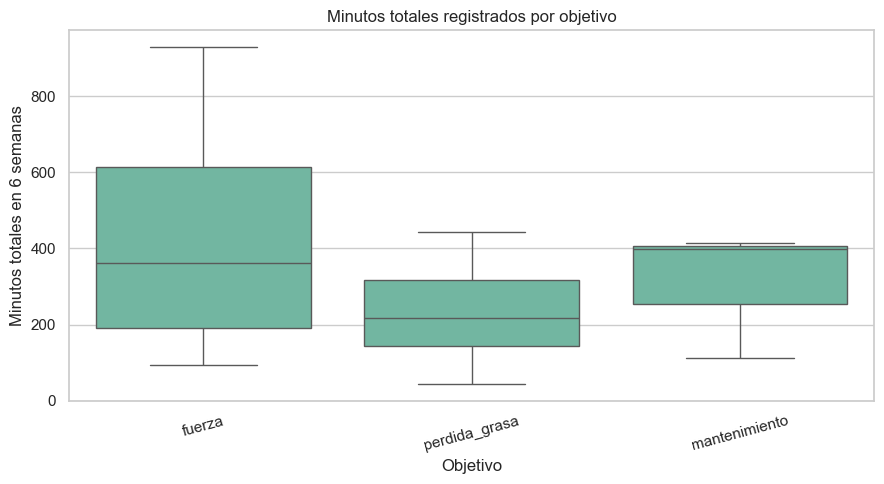

In [16]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=clean, x="objective", y="total_activity_minutes")
plt.title("Minutos totales registrados por objetivo")
plt.xlabel("Objetivo")
plt.ylabel("Minutos totales en 6 semanas")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

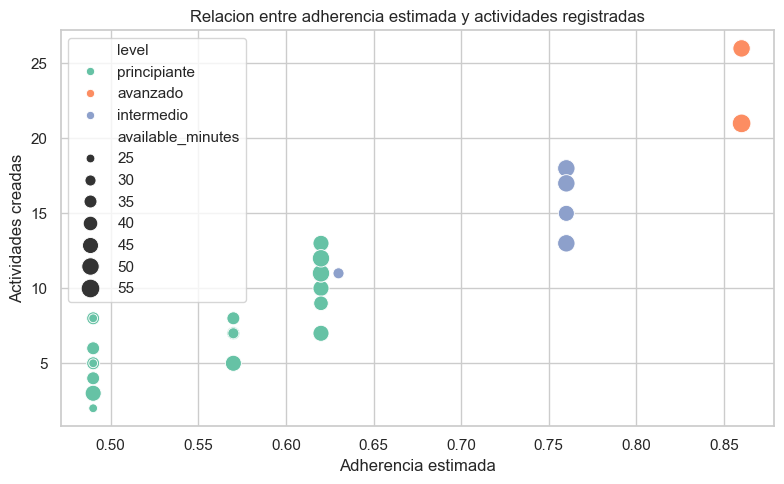

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=clean,
    x="adherence",
    y="activities_created",
    hue="level",
    size="available_minutes",
    sizes=(40, 180),
)
plt.title("Relacion entre adherencia estimada y actividades registradas")
plt.xlabel("Adherencia estimada")
plt.ylabel("Actividades creadas")
plt.tight_layout()
plt.show()

## 7. Tablas resumen tras la limpieza

In [18]:
summary_by_objective = clean.groupby("objective", as_index=False).agg(
    users=("participant_id", "count"),
    avg_bmi=("bmi", "mean"),
    avg_adherence=("adherence", "mean"),
    avg_activities=("activities_created", "mean"),
    avg_minutes=("total_activity_minutes", "mean"),
    avg_calories=("total_activity_calories", "mean"),
)

summary_by_objective.round(2)

,objective,users,avg_bmi,avg_adherence,avg_activities,avg_minutes,avg_calories
0,fuerza,16,24.29,0.63,11.69,411.88,3834.05
1,mantenimiento,3,27.00,0.67,11.00,308.00,2389.63
2,perdida_grasa,13,28.15,0.56,7.46,240.08,1997.62


In [19]:
summary_by_level = clean.groupby("level", as_index=False).agg(
    users=("participant_id", "count"),
    avg_training_days=("planned_training_days", "mean"),
    avg_available_minutes=("available_minutes", "mean"),
    avg_activities=("activities_created", "mean"),
    avg_minutes_per_activity=("minutes_per_activity", "mean"),
)

summary_by_level.round(2)

,level,users,avg_training_days,avg_available_minutes,avg_activities,avg_minutes_per_activity
0,avanzado,2,5.00,52.50,23.50,38.35
1,intermedio,6,3.50,45.83,15.33,32.12
2,principiante,24,2.38,37.71,7.42,31.62


## 8. Conclusiones exploratorias

- El dataset tiene una granularidad clara: una fila por usuario anonimizado de encuesta.
- La muestra contiene 32 participantes y combina variables demograficas, de salud, perfil fitness y actividad registrada.
- No se detectan duplicados por participante ni usuario.
- Los nulos se concentran principalmente en `age_group`, debido a fechas originales invalidas o no informadas. Se conserva la informacion marcandola como `no informado`.
- Las variables numericas principales presentan rangos coherentes: adherencia entre 0 y 1, dias de entrenamiento entre 1 y 7 y metricas de actividad no negativas.
- El objetivo mas frecuente se puede identificar visualmente con la grafica de barras.
- El histograma de BMI permite revisar la distribucion corporal inicial de la muestra.
- Las diferencias de minutos registrados por objetivo ayudan a comparar patrones basicos de actividad.
- La relacion entre adherencia y numero de actividades muestra si la simulacion de entrenamiento mantiene coherencia: a mayor adherencia, tiende a aumentar el numero de sesiones registradas.

Cambios aplicados durante la limpieza:
- Normalizacion de categorias de texto.
- Conversion de tipos numericos y booleanos.
- Tratamiento justificado de nulos en variables categoricas.
- Control de duplicados e incoherencias basicas.
- Creacion de variables derivadas para facilitar el analisis posterior.